# __Wearable dataset overview, EDA and preprocessing (updated)__

Ilina Durakovska

__Dataset:__ Wearable Device Dataset from Induced Stress and Structured Exercise Sessions \
__Physionet Link:__ [https://physionet.org/content/wearable-device-dataset/1.0.1/](https://physionet.org/content/wearable-device-dataset/1.0.1/) \
__Kaggle (unofficial) Link:__ [https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise](https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise)

In [5]:
import re
import shutil
import tempfile
import warnings
import numpy as np
import pandas as pd
import heartpy as hp
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import butter, filtfilt

In [6]:
warnings.filterwarnings("ignore")

---

# __Redifining the end goal__

Initially the end goal of this project was to have reliable real-time alerts when the body of a healthy person enters a stress state. Now our current goal has shifted - we want an accurate distinction between different stress states, with bigger latency allowed. 

Even though the current task is simpler, this creates a need to shift our existing data, or rather to redefine it. 

Before, the way we defined the state of a given window was by looking at its tail-end. This creates an issue, most metrics cannot be calculated on that small of a slice (mainly a limitation with HeartPy, but also other experiments have shown that in order to get reliable metrics you'd need to use at least about 30s of data). This resulted in segments with simmilar values for the calculated metrics, but different state labels. 

__The way we will approach making and labeling the data now is the following:__ \
Because larger latency is allowed, we can now use the whole segment to determine the label. Before we wanted to know "At what moment do we start transitioning into a stress state?", now we want to know "What state am I currently in?". \
Windows in which more than one state is present will be labeled as transitional, and depending on what we observe in the EDA they might be omitted from the training entirely.

With that being said, we can move onto generating our windowed dataset! 

For more details about the raw dataset we will be working with, take a look at the **Overview section** of the original `wearable_overview.ipynb` notebook. Since we will be working with the same data, everything mentioned there is applicable here.

---

# __Windowed dataset generation__

Most of this will be reused from `wearable_overview.ipynb`, I'll point out the differences where they appear.

In [20]:
DATASET_PATH = "wearable-device-dataset/Wearable_Dataset/"
STATES = ["AEROBIC", "ANAEROBIC", "STRESS"]

In [22]:
SIGNAL_HZ = {
    "BVP" : 64,
    "ACC" : 32,
    "EDA" : 4,
    "TEMP": 4,
    "HR"  : 1,
}

### _Helpers for handling the duplicated and invalid data:_

In [25]:
TRUNCATE_AT = {
    ("S02", "STRESS"): {
        "BVP" : 99091,
        "ACC" : 49545,
        "EDA" : 6195,
        "TEMP": 6195,
    }
}

In [27]:
INVALID_BVP = {("f07", "STRESS")}

## Loading the data:

### _Helper functions:_

In [31]:
def load_signal(filepath, col_names):
    """
    Load a fixed-rate Empatica E4 signal file.

    Returns
    -------
    values : np.ndarray raw signal values
    sample_rate : float
    start_time : pd.Timestamp (UTC)
    """
    raw = pd.read_csv(filepath, header=None)
    start_time = pd.to_datetime(raw.iloc[0, 0])
    sample_rate = float(raw.iloc[1, 0])
    data = raw.iloc[2:].reset_index(drop=True)
    data.columns = col_names
    data = data.apply(pd.to_numeric, errors="coerce")
    return data.values, sample_rate, start_time

In [33]:
def load_ibi(filepath):
    """
    Load IBI (irregular timestamps - one row per detected heartbeat).

    Returns
    -------
    offsets : np.ndarray (seconds from session start for each beat)
    ibi_sec : np.ndarray (duration of that inter-beat interval in seconds)
    """
    header = pd.read_csv(filepath, nrows=0)
    data = pd.read_csv(filepath, header=None, skiprows=1)
    data.columns = ["offset_sec", "ibi_sec"]
    data = data.apply(pd.to_numeric, errors="coerce").dropna()
    return data["offset_sec"].values, data["ibi_sec"].values

In [35]:
def safe_load(session_path, fname, cols):
    path = os.path.join(session_path, fname)
    if os.path.exists(path):
        vals, hz, start = load_signal(path, cols)
        return vals.astype(float), hz, start
    return None, None, None

In [37]:
def samples_in_window(hz, offset_start_sec, window_sec):
    """ How many samples of a signal fall inside a window starting at offset_start_sec. """
    s = int(offset_start_sec * hz)
    e = s + int(window_sec * hz)
    return s, e

In [39]:
def load_tags(session_path, bvp_start):
    """
    Load tags.csv and return each tag's offset in seconds from session start.

    Tags mark protocol phase transitions - each one was produced by the 
    researcher pressing the physical button on the E4 wristband.

    Parameters
    ----------
    session_path : str
    bvp_start : pd.Timestamp (session start time (row 0 of BVP.csv))

    Returns
    -------
    np.ndarray of float  tag offsets in seconds from session start, or empty array if tags.csv is missing
    """
    path = os.path.join(session_path, "tags.csv")
    if not os.path.exists(path):
        return np.array([])

    try:
        tags = pd.read_csv(path, header=None)
    except pd.errors.EmptyDataError:
        return np.array([])

    tags.columns = ["timestamp"]
    tags["timestamp"] = pd.to_datetime(tags["timestamp"])
    offsets = (tags["timestamp"] - bvp_start).dt.total_seconds().values
    return offsets

### _Whole-window labeling (replaces the old trailing-edge `assign_phase`):_

The original notebook labeled a window by voting over its trailing 10 seconds only. Since we're now inferring the class from the whole segment, `assign_window_label` below looks at every phase the *entire* window overlaps. If more than one state is present, the window is labeled `"transitional"` instead of being forced into one class.


In [42]:
def get_phase_segments(t_start_sec, t_end_sec, tag_offsets, phases):
    """
    Break a window [t_start_sec, t_end_sec) into the protocol-phase segments it overlaps.

    Unlike the original (label_window_sec-based) approach, this looks at the
    *entire* window rather than just its trailing edge, since we now label a
    window using everything inside it, not just the last few seconds.

    Parameters
    ----------
    t_start_sec : float - start of the window in seconds from session start
    t_end_sec : float - end of the window in seconds from session start
    tag_offsets : np.ndarray - tag positions in seconds (from load_tags)
    phases : list of (phase_name, state_label) tuples

    Returns
    -------
    list of (phase_idx, duration_sec) tuples, one per phase segment overlapping
    the window, in chronological order.
    """
    idx_start = int(np.searchsorted(tag_offsets, t_start_sec, side="right"))
    idx_end   = int(np.searchsorted(tag_offsets, t_end_sec,   side="right"))

    idx_start = min(idx_start, len(phases) - 1)
    idx_end   = min(idx_end,   len(phases) - 1)

    if idx_start == idx_end:
        return [(idx_end, t_end_sec - t_start_sec)]

    boundaries = [t_start_sec]
    for tag in tag_offsets:
        if t_start_sec < tag < t_end_sec:
            boundaries.append(tag)
    boundaries.append(t_end_sec)

    segments = []
    n_segments = len(boundaries) - 1
    for seg in range(n_segments):
        phase_idx = min(idx_start + seg, len(phases) - 1)
        duration  = boundaries[seg + 1] - boundaries[seg]
        segments.append((phase_idx, duration))
    return segments


def assign_window_label(t_start_sec, t_end_sec, tag_offsets, phases):
    """
    Determine the phase and state label for a *full* window.

    Because we now infer the class from the whole 60s segment (not just its
    tail), a window that overlaps more than one distinct state (e.g. the last
    few seconds of `rest` and the first few seconds of `stress`) can no longer
    be cleanly assigned to a single class. Such windows are labeled
    `"transitional"` instead of being forced into one of the four real states.

    Parameters
    ----------
    t_start_sec : float - start of the window in seconds from session start
    t_end_sec : float - end of the window in seconds from session start
    tag_offsets : np.ndarray - tag positions in seconds (from load_tags)
    phases : list of (phase_name, state_label) tuples

    Returns
    -------
    phase_name : str - dominant phase by duration, or the sequence of phases
        joined by "->" if the window is transitional
    state_label : str - one of the real state labels, or "transitional"
    """
    segments = get_phase_segments(t_start_sec, t_end_sec, tag_offsets, phases)

    states_present = {phases[idx][1] for idx, _ in segments}

    if len(states_present) > 1:
        ordered_phase_names = []
        for idx, _ in segments:
            name = phases[idx][0]
            if not ordered_phase_names or ordered_phase_names[-1] != name:
                ordered_phase_names.append(name)
        phase_name = "->".join(ordered_phase_names)
        return phase_name, "transitional"

    phase_durations = {}
    for idx, duration in segments:
        phase_durations[idx] = phase_durations.get(idx, 0) + duration
    dominant_idx = max(phase_durations, key=phase_durations.get)

    return phases[dominant_idx]


### _Split session helpers:_

The following functions handle Bluetooth dropout sessions (f14, S11, S16) where the recording split into `_a` and `_b` parts. They merge both parts into a single in-memory session with NaN-filled gap so the rest of the pipeline sees one continuous recording.

In [46]:
def read_e4_header(csv_path):
    """
    Return (start_timestamp, sample_rate) from an E4 CSV header.
    Handles multi-column signals like ACC where both header rows are comma-separated.

    Parameters
    ----------
    csv_path : str

    Returns
    -------
    start : pd.Timestamp
    rate : float
    """
    with open(csv_path, "r") as fh:
        lines = [fh.readline().strip() for _ in range(2)]
    start = pd.Timestamp(lines[0].split(",")[0])
    rate  = float(lines[1].split(",")[0])
    return start, rate

In [48]:
def load_raw_values(csv_path):
    """
    Return the data rows of an E4 CSV as a numpy array, skipping the 2-row header.

    Parameters
    ----------
    csv_path : str

    Returns
    -------
    np.ndarray, shape (n_samples, n_columns)
    """
    return pd.read_csv(csv_path, header=None, skiprows=2).values

In [50]:
def fill_gap_and_concat(path_a_sig, path_b_sig, out_path):
    """
    Merge two parts of a split session signal into a single CSV.

    The gap between the end of _a and the start of _b is filled with NaN rows
    so that sample indices remain aligned with wall-clock time. This means
    tag offsets computed from the merged file stay valid.

    Parameters
    ----------
    path_a_sig : str - path to the _a signal CSV
    path_b_sig : str - path to the _b signal CSV
    out_path : str - destination path for the merged CSV
    """
    if not os.path.exists(path_a_sig):
        if os.path.exists(path_b_sig):
            shutil.copy(path_b_sig, out_path)
        return

    start_a, rate_a = read_e4_header(path_a_sig)
    data_a = load_raw_values(path_a_sig)
    n_cols = data_a.shape[1] if data_a.ndim > 1 else 1

    if os.path.exists(path_b_sig):
        start_b, _ = read_e4_header(path_b_sig)
        data_b = load_raw_values(path_b_sig)

        end_a = start_a + pd.Timedelta(seconds=len(data_a) / rate_a)
        gap_sec = max((start_b - end_a).total_seconds(), 0)
        gap_samples = int(round(gap_sec * rate_a))

        if gap_samples > 0:
            gap_fill = np.full((gap_samples, n_cols), np.nan)
            merged_data = np.vstack([data_a.reshape(-1, n_cols),
                                     gap_fill,
                                     data_b.reshape(-1, n_cols)])
        else:
            merged_data = np.vstack([data_a.reshape(-1, n_cols),
                                     data_b.reshape(-1, n_cols)])
    else:
        merged_data = data_a.reshape(-1, n_cols)

    with open(path_a_sig, "r") as fh:
        header_lines = [fh.readline() for _ in range(2)]

    with open(out_path, "w", newline="") as fh:
        fh.writelines(header_lines)
        for row in merged_data:
            fh.write(",".join("" if (isinstance(v, float) and np.isnan(v)) else str(v) for v in row ) + "\n")

In [52]:
def merge_tags(path_a_tags, path_b_tags, out_path):
    """
    Concatenate tag timestamps from two split session parts into one file.

    Tags are already in wall-clock order, so simple concatenation is correct.

    Parameters
    ----------
    path_a_tags : str
    path_b_tags : str
    out_path : str
    """
    lines = []
    for p in [path_a_tags, path_b_tags]:
        if os.path.exists(p):
            with open(p, "r") as fh:
                content = fh.read().strip()
                if content:
                    lines.append(content)
    with open(out_path, "w") as fh:
        fh.write("\n".join(lines) + ("\n" if lines else ""))

In [54]:
SIGNALS = ["BVP.csv", "EDA.csv", "TEMP.csv", "ACC.csv", "HR.csv", "IBI.csv"]

In [56]:
def merge_split_sessions(path_a, path_b):
    """
    Merge two split session folders (_a and _b) into a single temporary directory.

    Each signal is gap-filled (NaN) over the Bluetooth dropout interval so that
    sample indices stay aligned with wall-clock time and tag offsets remain valid.
    The temporary directory is written to disk and its path is returned; the caller
    is responsible for deleting it with shutil.rmtree() after use.

    Parameters
    ----------
    path_a : str - folder for the _a (first) part
    path_b : str - folder for the _b (second) part

    Returns
    -------
    str path to the temporary merged directory
    """
    tmp = tempfile.mkdtemp(prefix="merged_session_")

    for sig in SIGNALS:
        fill_gap_and_concat(
            os.path.join(path_a, sig),
            os.path.join(path_b, sig),
            os.path.join(tmp, sig),
        )

    merge_tags(
        os.path.join(path_a, "tags.csv"),
        os.path.join(path_b, "tags.csv"),
        os.path.join(tmp, "tags.csv"),
    )

    return tmp

In [58]:
def get_base_patient_id(folder_name):
    """
    Strip a trailing _a / _b suffix to get the canonical patient ID.

    Parameters
    ----------
    folder_name : str

    Returns
    -------
    str
    """
    return re.sub(r"_[ab]$", "", folder_name)

In [60]:
def group_split_patients(patients):
    """
    Group _a / _b folder pairs by their canonical patient ID.

    Parameters
    ----------
    patients : list of str  — sorted folder names as returned by os.listdir

    Returns
    -------
    list of (canonical_id, [folder_names]) tuples, sorted by canonical_id
    """
    groups = {}
    for p in patients:
        base = get_base_patient_id(p)
        groups.setdefault(base, []).append(p)
    return sorted(groups.items())


### _State label values:_
- `"rest"` -> baseline, subject sitting/standing still (no pedaling), inter-task rest periods
- `"aerobic"` -> sustained aerobic exercise blocks
- `"anaerobic"` -> sprint blocks
- `"stress"` -> cognitive stress tasks (TMCT, opinion tasks, subtraction)
- `"recovery"` -> post-exertion cooldown periods where the subject is still pedaling against zero resistance (aerobic `cooldown`, anaerobic `cooldown_1..4`). Per the PhysioNet methods text, these are explicitly *not* the same as the final "remained still" rest period - HR is still actively decaying from exertion rather than at true baseline, and the protocol diagrams draw "Cool Down" in its own distinct color, separate from "Rest"/"Baseline". Previously these were folded into `"rest"`, which conflated active recovery with true rest.
- `"transitional"` -> the window overlaps more than one of the above states (e.g. the end of a `rest` phase and the start of a `stress` phase). Since we now label a window using the whole 60s segment instead of just its tail, these windows can't be cleanly assigned to a single class and will not be used for training.


### _Protocol phase maps:_

__Note (AEROBIC, S cohort):__ the original version of this map prepended a spurious `pre_protocol` phase and had no trailing `rest` phase (it ended at `cooldown`), while every other cohort/protocol combination starts directly at an active phase and ends with a genuine still-rest phase. Cross-checking the actual `tags.csv` offsets for S16 against the diagram's expected block durations confirmed the tag boundaries actually correspond to `warmup -> 60...110rpm -> cooldown -> rest` (13 phases, 12 tags, matching durations within ~15s per block except one subject-specific outlier on `90rpm`). The tag *count* check alone (`len(phases)-1`) could not have caught this, since both the old and corrected phase lists have 13 phases / 12 tags — only comparing actual segment durations against the diagram exposed the bug. Fixed below.


In [64]:
PROTOCOL_PHASES = {
    ("STRESS", "S"): [
        ("baseline",          "rest"),
        ("stroop",            "stress"),
        ("stroop",            "stress"),
        ("first_rest",        "rest"),
        ("first_rest",        "rest"),
        ("tmct",              "stress"),
        ("second_rest",       "rest"),
        ("real_opinion",      "stress"),
        ("real_opinion",      "stress"),
        ("opposite_opinion",  "stress"),
        ("opposite_opinion",  "stress"),
        ("subtract_test",     "stress"),
        ("subtract_test",     "stress"),
        ("end",               "rest"),
    ],

    ("STRESS", "f"): [
        ("baseline",          "rest"),
        ("baseline",          "rest"),
        ("tmct",              "stress"),
        ("first_rest",        "rest"),
        ("real_opinion",      "stress"),
        ("opposite_opinion",  "stress"),
        ("second_rest",       "rest"),
        ("subtract_test",     "stress"),
        ("subtract_test",     "stress"),
        ("end",               "rest"),
    ],

    ("AEROBIC", "S"): [
        ("warmup",        "aerobic"),
        ("60rpm",         "aerobic"),
        ("70rpm",         "aerobic"),
        ("75rpm",         "aerobic"),
        ("80rpm",         "aerobic"),
        ("85rpm",         "aerobic"),
        ("90rpm",         "aerobic"),
        ("95rpm",         "aerobic"),
        ("100rpm",        "aerobic"),
        ("105rpm",        "aerobic"),
        ("110rpm",        "aerobic"),
        ("cooldown",      "recovery"),
        ("rest",          "rest"),
    ],

    ("AEROBIC", "f"): [
        ("pre_protocol",  "rest"),
        ("warmup",        "aerobic"),
        ("70rpm",         "aerobic"),
        ("75rpm",         "aerobic"),
        ("80rpm",         "aerobic"),
        ("85rpm",         "aerobic"),
        ("90_95rpm",      "aerobic"),
        ("cooldown",      "recovery"),
        ("rest",          "rest"),
    ],

    ("ANAEROBIC", "S"): [
        ("warmup",       "rest"),
        ("sprint_1",     "anaerobic"),
        ("cooldown_1",   "recovery"),
        ("sprint_2",     "anaerobic"),
        ("cooldown_2",   "recovery"),
        ("sprint_3",     "anaerobic"),
        ("cooldown_3",   "recovery"),
        ("rest",         "rest"),
    ],

    ("ANAEROBIC", "f"): [
        ("pre_protocol",  "rest"),
        ("warmup",        "rest"),
        ("sprint_1",      "anaerobic"),
        ("cooldown_1",    "recovery"),
        ("sprint_2",      "anaerobic"),
        ("cooldown_2",    "recovery"),
        ("sprint_3",      "anaerobic"),
        ("cooldown_3",    "recovery"),
        ("sprint_4",      "anaerobic"),
        ("cooldown_4",    "recovery"),
        ("rest",          "rest"),
        ("end",           "rest"),
    ],
}


In [66]:
STATE_LABEL_MAP = {"rest": 0, "aerobic": 1, "anaerobic": 2, "stress": 3, "recovery": 4, "transitional": 5}


### _Building the windows:_

In [69]:
def build_windows(patient_id, session_path, label, window_sec=60, overlap=55/60):
    """
    Segment one patient session into overlapping windows and extract features.

    Parameters
    ----------
    patient_id : str (e.g. "f01")
    session_path : str (path to the folder with CSV files)
    label : str ("AEROBIC", "ANAEROBIC", or "STRESS")
    window_sec : int (window size in seconds)
    overlap : float (fractional overlap between windows, 0-<1)

    Returns
    -------
    pd.DataFrame with one row per window
    """
    rows = []

    base_id = patient_id.rstrip("_ab")
    cohort  = "S" if base_id[0].upper() == "S" else "f"
    phases  = PROTOCOL_PHASES.get((label, cohort))

    # ── Load BVP ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    bvp_path = os.path.join(session_path, "BVP.csv")
    if not os.path.exists(bvp_path):
        print(f"  [{patient_id}] BVP.csv missing - skipping")
        return pd.DataFrame()

    bvp_vals, bvp_hz, bvp_start = load_signal(bvp_path, ["bvp"])
    bvp_vals = bvp_vals[:, 0].astype(float)

    trunc = TRUNCATE_AT.get((patient_id, label), {})
    if "BVP" in trunc:
        bvp_vals = bvp_vals[:trunc["BVP"]]

    # Bandpass filter once for the whole session (0.5–8 Hz = heartbeat band)
    bvp_filtered = hp.filter_signal(bvp_vals, cutoff=[0.5, 8], sample_rate=bvp_hz, order=3, filtertype="bandpass")

    # ── Load tags (phase boundaries) ─────────────────────────────────────────────────────────────────────────────────────────────────────────
    tag_offsets = load_tags(session_path, bvp_start)

    expected_n_tags = len(phases) - 1 if phases else None
    if phases is not None and len(tag_offsets) != expected_n_tags:
        print(f"  [{patient_id}/{label}] WARNING: expected {expected_n_tags} tags, "
              f"got {len(tag_offsets)} — phase labels may be misaligned")

    # ── Load supporting signals ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
    eda_vals, eda_hz, _ = safe_load(session_path, "EDA.csv", ["eda"])
    temp_vals, temp_hz, _ = safe_load(session_path, "TEMP.csv", ["temp"])
    acc_vals, acc_hz, _ = safe_load(session_path, "ACC.csv", ["acc_x", "acc_y", "acc_z"])

    if eda_vals is not None and "EDA" in trunc: eda_vals = eda_vals [:trunc["EDA"]]
    if temp_vals is not None and "TEMP" in trunc: temp_vals = temp_vals[:trunc["TEMP"]]
    if acc_vals is not None and "ACC" in trunc: acc_vals = acc_vals [:trunc["ACC"]]

    # ── Pre-compute phasic EDA filter coefficients (0.05 Hz high-pass) ───────────────────────────────────────────────────────────────────────
    # EDA = tonic (slow drift) + phasic (fast skin conductance responses).
    # A simple 2nd-order Butterworth high-pass at 0.05 Hz removes the tonic 
    # baseline, leaving the phasic bursts that are most diagnostic for stress.
    if eda_vals is not None:
        b_hp, a_hp = butter(2, 0.05 / (eda_hz / 2), btype="high")
        eda_flat = eda_vals[:, 0].astype(float)
        eda_phasic_full = filtfilt(b_hp, a_hp, eda_flat)
    else:
        eda_phasic_full = None

    # ── Window parameters ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    bvp_win  = int(window_sec * bvp_hz)
    bvp_step = int(bvp_win * (1 - overlap))

    # Acceleration magnitude threshold for motion-artifact flagging.
    # 1/64g units; ~0.5g peak-to-peak is a commonly used threshold in the
    # wearable literature for detecting significant wrist movement.
    ACC_MOTION_THRESHOLD_STD = 8

    HP_METRICS = ["bpm", "ibi", "sdnn", "rmssd", "pnn20", "pnn50", "hr_mad", "sd1", "sd2", "sd1/sd2", "breathingrate"]

    n_total = len(bvp_filtered)

    for win_idx, bvp_start_sample in enumerate(range(0, n_total - bvp_win + 1, bvp_step)):
        bvp_end_sample = bvp_start_sample + bvp_win
        offset_start = bvp_start_sample / bvp_hz
        offset_end = offset_start + window_sec

        # ── Phase / state labelling (whole window) ────────────────────────────────────────────────────────────────────────────────────────────
        # Uses every phase the window overlaps, not just its trailing edge.
        # If more than one state is present, the window is "transitional".
        if phases is not None and len(tag_offsets) > 0:
            phase_name, state_label = assign_window_label(offset_start, offset_end, tag_offsets, phases)
        else:
            phase_name  = "unknown"
            state_label = label.lower()

        row = {
            "patient_id"  : patient_id,
            "session" : label,
            "phase" : phase_name,
            "state_label" : state_label,
            "state_label_int": STATE_LABEL_MAP.get(state_label, -1),
            "window_index": win_idx,
            "t_start_sec" : round(offset_start, 3),
            "t_end_sec" : round(offset_end,   3),
        }

        # ── HeartPy on BVP slice ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
        bvp_slice = bvp_filtered[bvp_start_sample:bvp_end_sample]
        try:
            wd, m = hp.process(bvp_slice, sample_rate=bvp_hz, calc_freq=False)
            for metric in HP_METRICS:
                val = m.get(metric, np.nan)
                row[f"hp_{metric}"] = float(val) if not isinstance(val, str) else np.nan
            row["hp_quality_flag"] = 0
        except Exception:
            for metric in HP_METRICS:
                row[f"hp_{metric}"] = np.nan
            row["hp_quality_flag"] = 1

        # ── EDA (full window only - tail metrics dropped, see redo notebook intro) ───────────────────────────────────────────────────────────
        if eda_vals is not None:
            s, e = samples_in_window(eda_hz, offset_start, window_sec)
            chunk_tonic  = eda_vals[s:e, 0] if e <= len(eda_vals) else eda_vals[s:, 0]
            chunk_phasic = eda_phasic_full[s:e] if e <= len(eda_phasic_full) else eda_phasic_full[s:]
            if len(chunk_tonic) > 0:
                row["eda_mean"] = float(np.nanmean(chunk_tonic))
                row["eda_std"] = float(np.nanstd(chunk_tonic))  if len(chunk_tonic) > 1 else np.nan
                row["eda_phasic_mean"] = float(np.nanmean(chunk_phasic))
                row["eda_phasic_std"] = float(np.nanstd(chunk_phasic)) if len(chunk_phasic) > 1 else np.nan
                row["eda_phasic_max"] = float(np.nanmax(chunk_phasic))
            else:
                row["eda_mean"] = row["eda_std"] = np.nan
                row["eda_phasic_mean"] = row["eda_phasic_std"] = row["eda_phasic_max"] = np.nan
        else:
            row["eda_mean"] = row["eda_std"] = np.nan
            row["eda_phasic_mean"] = row["eda_phasic_std"] = row["eda_phasic_max"] = np.nan

        # ── TEMP (full window only) ───────────────────────────────────────────────────────────────────────────────────────────────────────────
        if temp_vals is not None:
            s, e = samples_in_window(temp_hz, offset_start, window_sec)
            chunk = temp_vals[s:e, 0] if e <= len(temp_vals) else temp_vals[s:, 0]
            row["temp_mean"] = float(np.nanmean(chunk)) if len(chunk) > 0 else np.nan
        else:
            row["temp_mean"] = np.nan

        # ── ACC (full window only) ────────────────────────────────────────────────────────────────────────────────────────────────────────────
        if acc_vals is not None:
            s, e = samples_in_window(acc_hz, offset_start, window_sec)
            chunk = acc_vals[s:e] if e <= len(acc_vals) else acc_vals[s:]
            if len(chunk) > 0:
                mag = np.sqrt(chunk[:, 0]**2 + chunk[:, 1]**2 + chunk[:, 2]**2)
                acc_mean = float(np.nanmean(mag))
                acc_std  = float(np.nanstd(mag))
                row["acc_mag_mean"] = acc_mean
                row["acc_mag_std"] = acc_std
                row["motion_artifact_flag"] = int(acc_std > ACC_MOTION_THRESHOLD_STD)
            else:
                row["acc_mag_mean"] = row["acc_mag_std"] = np.nan
                row["motion_artifact_flag"] = 0
        else:
            row["acc_mag_mean"] = row["acc_mag_std"] = np.nan
            row["motion_artifact_flag"] = 0

        rows.append(row)

    return pd.DataFrame(rows)


### _Building the dataframe:_

In [72]:
WINDOW_SEC = 60
OVERLAP = 55/60

For each trial, we build their windows and add tem to the dataset:

In [75]:
all_dfs = []

for state in STATES:
    state_path = os.path.join(DATASET_PATH, state)
    if not os.path.isdir(state_path):
        print(f"Skipping {state} — not found at {state_path}")
        continue

    raw_patients = sorted([
        p for p in os.listdir(state_path)
        if os.path.isdir(os.path.join(state_path, p))
    ])
    patient_groups = group_split_patients(raw_patients)
    print(f"\n[{state}] {len(patient_groups)} patient(s): {[pid for pid, _ in patient_groups]}")

    for patient_id, folders in patient_groups:
        tmp_dir = None 

        if (patient_id, state) in INVALID_BVP:
            print(f"  {patient_id}... skipped (invalid sensor placement)")
            continue

        print(f"  {patient_id}...", end=" ", flush=True)

        try:
            if len(folders) == 2:
                folders_sorted = sorted(folders)  # ensures _a before _b
                path_a = os.path.join(state_path, folders_sorted[0])
                path_b = os.path.join(state_path, folders_sorted[1])
                session_path = merge_split_sessions(path_a, path_b)
                tmp_dir = session_path
            else:
                session_path = os.path.join(state_path, folders[0])

            df = build_windows(patient_id, session_path, state,
                               window_sec=WINDOW_SEC, overlap=OVERLAP)
        finally:
            if tmp_dir and os.path.isdir(tmp_dir):
                shutil.rmtree(tmp_dir, ignore_errors=True)

        if len(df) > 0:
            all_dfs.append(df)
            print(f"{len(df)} windows")
        else:
            print("skipped")

dataset = pd.concat(all_dfs, ignore_index=True)

print(f"\nFinished: {len(dataset)} total windows  |  {WINDOW_SEC}s window  |  {int(OVERLAP*60)}s stride")


[AEROBIC] 30 patient(s): ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']
  S01... 397 windows
  S02... 396 windows
  S03...   [S03/AEROBIC] WARNING: expected 12 tags, got 7 — phase labels may be misaligned
276 windows
  S04... 397 windows
  S05... 384 windows
  S06... 402 windows
  S07...   [S07/AEROBIC] WARNING: expected 12 tags, got 9 — phase labels may be misaligned
324 windows
  S08... 394 windows
  S09... 396 windows
  S10... 396 windows
  S11...   [S11/AEROBIC] WARNING: expected 12 tags, got 11 — phase labels may be misaligned
372 windows
  S13... 406 windows
  S14... 423 windows
  S15... 396 windows
  S16... 397 windows
  S17... 396 windows
  S18... 397 windows
  f01... 528 windows
  f02... 340 windows
  f03... 528 windows
  f04... 492 windows
  f05... 604 windows
  f06... 531 windows
  f07... 455 windows
  f08... 466

In [76]:
print(f"\nState label distribution:")
print(dataset["state_label"].value_counts())
print(f"\nHeartPy quality failures: {dataset['hp_quality_flag'].sum()} / {len(dataset)} "
      f"({100*dataset['hp_quality_flag'].mean():.1f}%)")


State label distribution:
state_label
rest            16060
aerobic          9117
transitional     5381
stress           4984
recovery         4128
anaerobic          13
Name: count, dtype: int64

HeartPy quality failures: 755 / 39683 (1.9%)


In [77]:
print(f"\nMotion-artifact windows by state:")
ma = dataset.groupby("state_label")["motion_artifact_flag"].agg(
    flagged="sum", total="count"
)
ma["pct"] = (ma["flagged"] / ma["total"] * 100).round(1)
print(ma.to_string())


Motion-artifact windows by state:
              flagged  total  pct
state_label                      
aerobic           542   9117  5.9
anaerobic           0     13  0.0
recovery          348   4128  8.4
rest             1334  16060  8.3
stress             20   4984  0.4
transitional      308   5381  5.7


### _Checking the data:_

In [79]:
dataset.head(10)

,patient_id,session,phase,state_label,state_label_int,window_index,t_start_sec,t_end_sec,hp_bpm,hp_ibi,...,hp_quality_flag,eda_mean,eda_std,eda_phasic_mean,eda_phasic_std,eda_phasic_max,temp_mean,acc_mag_mean,acc_mag_std,motion_artifact_flag
0,S01,AEROBIC,warmup,aerobic,1,0,0.0,60.0,99.426172,603.462838,...,0,0.188251,0.015562,0.006159,0.027812,0.158108,35.805833,63.173748,1.733079,0
1,S01,AEROBIC,warmup,aerobic,1,1,5.0,65.0,99.355904,603.889628,...,0,0.190242,0.004689,-0.001077,0.005400,0.030725,35.796667,63.175358,1.407620,0
2,S01,AEROBIC,warmup,aerobic,1,2,10.0,70.0,99.310345,604.166667,...,0,0.191320,0.004880,-0.001084,0.003781,0.005916,35.789667,63.183880,1.417658,0
3,S01,AEROBIC,warmup,aerobic,1,3,15.0,75.0,98.942229,606.414474,...,0,0.192500,0.004806,-0.000211,0.002334,0.005916,35.781667,63.190549,1.434628,0
4,S01,AEROBIC,warmup,aerobic,1,4,20.0,80.0,98.382706,609.863281,...,0,0.193754,0.004574,0.000037,0.001824,0.005916,35.772167,63.211475,1.473235,0
5,S01,AEROBIC,warmup,aerobic,1,5,25.0,85.0,97.696840,614.144737,...,0,0.195094,0.004558,0.000058,0.001822,0.005916,35.761333,63.218793,1.472237,0
6,S01,AEROBIC,warmup,aerobic,1,6,30.0,90.0,97.360960,616.263441,...,0,0.196359,0.004512,0.000035,0.001818,0.005916,35.750167,63.245586,1.470551,0
7,S01,AEROBIC,warmup,aerobic,1,7,35.0,95.0,97.006181,618.517287,...,0,0.197491,0.004593,-0.000017,0.001835,0.005916,35.738333,63.241830,1.449537,0
8,S01,AEROBIC,warmup,aerobic,1,8,40.0,100.0,97.387510,616.095430,...,0,0.198639,0.004464,-0.000006,0.001820,0.005916,35.725667,63.243171,1.444576,0
9,S01,AEROBIC,warmup,aerobic,1,9,45.0,105.0,96.736035,620.244565,...,0,0.199733,0.004316,0.000008,0.001802,0.005916,35.713667,63.241718,1.463888,0


In [80]:
dataset.tail(10)

,patient_id,session,phase,state_label,state_label_int,window_index,t_start_sec,t_end_sec,hp_bpm,hp_ibi,...,hp_quality_flag,eda_mean,eda_std,eda_phasic_mean,eda_phasic_std,eda_phasic_max,temp_mean,acc_mag_mean,acc_mag_std,motion_artifact_flag
39673,f18,STRESS,end,rest,0,607,3035.0,3095.0,69.700840,860.821759,...,0,0.338484,0.015061,0.000112,0.003887,0.01639,31.453000,64.216116,0.891968,0
39674,f18,STRESS,end,rest,0,608,3040.0,3100.0,70.355442,852.812500,...,0,0.342118,0.017594,0.000029,0.003890,0.01639,31.449000,64.159518,0.897634,0
39675,f18,STRESS,end,rest,0,609,3045.0,3105.0,69.844098,859.056122,...,0,0.345799,0.019102,-0.000032,0.003906,0.01639,31.447333,64.106291,0.905234,0
39676,f18,STRESS,end,rest,0,610,3050.0,3110.0,69.818182,859.375000,...,0,0.349646,0.020132,-0.000045,0.003911,0.01639,31.443333,64.046988,0.913176,0
39677,f18,STRESS,end,rest,0,611,3055.0,3115.0,72.200557,831.018519,...,0,0.353568,0.020605,-0.000028,0.003921,0.01639,31.439667,64.002209,0.908300,0
39678,f18,STRESS,end,rest,0,612,3060.0,3120.0,70.650767,849.247685,...,0,0.357532,0.020546,0.000301,0.004157,0.01639,31.436333,63.948648,0.901746,0
39679,f18,STRESS,end,rest,0,613,3065.0,3125.0,71.883190,834.687500,...,0,0.360152,0.019330,-0.000185,0.004990,0.01639,31.433000,63.933287,1.158493,0
39680,f18,STRESS,end,rest,0,614,3070.0,3130.0,70.370104,852.634804,...,0,0.363231,0.017454,-0.000058,0.005021,0.01639,31.428000,63.948624,1.210840,0
39681,f18,STRESS,end,rest,0,615,3075.0,3135.0,70.500000,851.063830,...,0,0.365963,0.014870,-0.000149,0.005003,0.01639,31.424333,63.933891,1.541879,0
39682,f18,STRESS,end,rest,0,616,3080.0,3140.0,70.645953,849.305556,...,0,0.368610,0.011425,-0.000033,0.005095,0.01639,31.418667,63.940179,1.543067,0


In [81]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39683 entries, 0 to 39682
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            39683 non-null  object 
 1   session               39683 non-null  object 
 2   phase                 39683 non-null  object 
 3   state_label           39683 non-null  object 
 4   state_label_int       39683 non-null  int64  
 5   window_index          39683 non-null  int64  
 6   t_start_sec           39683 non-null  float64
 7   t_end_sec             39683 non-null  float64
 8   hp_bpm                38765 non-null  float64
 9   hp_ibi                38765 non-null  float64
 10  hp_sdnn               38765 non-null  float64
 11  hp_rmssd              38173 non-null  float64
 12  hp_pnn20              38173 non-null  float64
 13  hp_pnn50              38173 non-null  float64
 14  hp_hr_mad             38765 non-null  float64
 15  hp_sd1             

In [82]:
dataset.isnull().sum()

patient_id                 0
session                    0
phase                      0
state_label                0
state_label_int            0
window_index               0
t_start_sec                0
t_end_sec                  0
hp_bpm                   918
hp_ibi                   918
hp_sdnn                  918
hp_rmssd                1510
hp_pnn20                1510
hp_pnn50                1510
hp_hr_mad                918
hp_sd1                  1510
hp_sd2                  1510
hp_sd1/sd2              1986
hp_breathingrate        1508
hp_quality_flag            0
eda_mean                   0
eda_std                    0
eda_phasic_mean            0
eda_phasic_std             0
eda_phasic_max             0
temp_mean                  0
acc_mag_mean              39
acc_mag_std               39
motion_artifact_flag       0
dtype: int64

The presence of **null values** in the HeartPy metrics means HeartPy could not detect enough peaks in that window to calculate HRV - this is flagged by `hp_quality_flag = 1`. 

Causes include genuine signal noise, poor sensor contact, and (in aerobic/anaerobic sessions) motion artifacts moving the wrist strongly enough to corrupt the BVP. Because we cannot distinguish signal quality failures from physiologically meaningful low-amplitude windows, the safest approach is to drop these rows. The `motion_artifact_flag` is retained in the clean dataset so downstream modelling steps can inspect or further filter high-motion windows independently.

In [85]:
dataset_clean = dataset.dropna()
dataset_clean = dataset_clean.reset_index(drop=True)

In [86]:
print(f"Kept {len(dataset_clean)} of {len(dataset)} windows "
      f"({100*len(dataset_clean)/len(dataset):.1f}%) — "
      f"{len(dataset) - len(dataset_clean)} windows dropped (all HeartPy quality failures)")

Kept 37652 of 39683 windows (94.9%) — 2031 windows dropped (all HeartPy quality failures)


In [87]:
print(f"\nState label distribution after cleaning:")
print(dataset_clean["state_label"].value_counts())

print(f"\nMotion-artifact windows by state (clean set):")
ma = dataset_clean.groupby("state_label")["motion_artifact_flag"].agg(
    flagged="sum", total="count"
)
ma["pct"] = (ma["flagged"] / ma["total"] * 100).round(1)
print(ma.to_string())


State label distribution after cleaning:
state_label
rest            14930
aerobic          8892
transitional     5014
stress           4729
recovery         4074
anaerobic          13
Name: count, dtype: int64

Motion-artifact windows by state (clean set):
              flagged  total  pct
state_label                      
aerobic           517   8892  5.8
anaerobic           0     13  0.0
recovery          346   4074  8.5
rest             1265  14930  8.5
stress             20   4729  0.4
transitional      306   5014  6.1


In [88]:
# Sanity check:
dataset_clean.isnull().sum()

patient_id              0
session                 0
phase                   0
state_label             0
state_label_int         0
window_index            0
t_start_sec             0
t_end_sec               0
hp_bpm                  0
hp_ibi                  0
hp_sdnn                 0
hp_rmssd                0
hp_pnn20                0
hp_pnn50                0
hp_hr_mad               0
hp_sd1                  0
hp_sd2                  0
hp_sd1/sd2              0
hp_breathingrate        0
hp_quality_flag         0
eda_mean                0
eda_std                 0
eda_phasic_mean         0
eda_phasic_std          0
eda_phasic_max          0
temp_mean               0
acc_mag_mean            0
acc_mag_std             0
motion_artifact_flag    0
dtype: int64

In [143]:
dataset_clean.to_csv("wearable_dataset_windows_updated.csv")

### _Column dictionary — `wearable_dataset_windows_updated.csv`_

| Column | Type | Description |
|--------|------|-------------|
| `patient_id` | str | Participant identifier (e.g. `f01`, `S03`). Prefix `f` = V2 cohort (female), `S` = V1 cohort (male). Split sessions carry a suffix (e.g. `S11_a`). |
| `session` | str | Protocol type for this recording: `AEROBIC`, `ANAEROBIC`, or `STRESS`. |
| `phase` | str | Fine-grained phase within the session (e.g. `tmct`, `sprint_1`, `85rpm`, `baseline`). Derived from event tag offsets and the cohort-specific protocol map. For `transitional` windows, this instead holds the sequence of phases the window overlaps, joined by `->` (e.g. `baseline->stroop`). |
| `state_label` | str | Physiological state of the subject during this window: `rest`, `aerobic`, `anaerobic`, `stress`, `recovery`, or `transitional`. Derived from every phase the *whole* 60s window overlaps (not just its tail) — if the window spans more than one of the five real states, it is labeled `transitional`. `recovery` covers post-exertion cooldown periods (still pedaling, zero resistance) and is kept separate from `rest` (subject fully still) per the PhysioNet methods text and the protocol diagrams. This is the model target; `transitional` windows are excluded from training. |
| `state_label_int` | int | Integer encoding of `state_label`: rest=0, aerobic=1, anaerobic=2, stress=3, recovery=4, transitional=5. |
| `window_index` | int | Sequential index of this window within its session (0-based). |
| `t_start_sec` | float | Window start time in seconds from session start. |
| `t_end_sec` | float | Window end time in seconds from session start. |
| `hp_bpm` | float | Mean heart rate in BPM computed by HeartPy from the BVP slice. |
| `hp_ibi` | float | Mean inter-beat interval in milliseconds (HeartPy). |
| `hp_sdnn` | float | Standard deviation of NN intervals (ms) - overall HRV. Lower values indicate reduced variability, a stress marker. |
| `hp_rmssd` | float | Root mean square of successive RR differences (ms) - short-term HRV, reflects parasympathetic activity. |
| `hp_pnn20` | float | Proportion of successive RR intervals differing by >20 ms. |
| `hp_pnn50` | float | Proportion of successive RR intervals differing by >50 ms. More conservative HRV measure. |
| `hp_hr_mad` | float | Median absolute deviation of heart rate - robust spread measure. |
| `hp_sd1` | float | Poincaré plot SD1: short-term RR variability (parasympathetic). |
| `hp_sd2` | float | Poincaré plot SD2: long-term RR variability (sympathovagal). |
| `hp_sd1/sd2` | float | Ratio of SD1 to SD2 - autonomic balance indicator. |
| `hp_breathingrate` | float | Estimated respiratory rate (breaths/min) derived from HRV oscillations. |
| `hp_quality_flag` | int | `1` if HeartPy failed to detect enough peaks (window dropped in clean set); `0` otherwise. |
| `eda_mean` | float | Mean electrodermal activity (tonic level, µS) over the full 60 s window. Reflects slow sympathetic arousal baseline. |
| `eda_std` | float | Standard deviation of tonic EDA over the full 60 s window - captures gradual drift. |
| `eda_phasic_mean` | float | Mean of the phasic EDA component (high-pass filtered at 0.05 Hz, µS) over the full 60 s window. Reflects fast skin conductance responses linked to sympathetic nervous system bursts. |
| `eda_phasic_std` | float | Std of phasic EDA over the full 60 s window - spread of skin conductance response amplitude. |
| `eda_phasic_max` | float | Peak phasic EDA value over the full 60 s window - captures the strongest single stress response. |
| `temp_mean` | float | Mean skin surface temperature (°C) over the full 60 s window. Drops transiently during acute stress (vasoconstriction); rises during exercise. |
| `acc_mag_mean` | float | Mean 3-axis acceleration magnitude (units of 1/64 g) over the full 60 s window - proxy for activity intensity. |
| `acc_mag_std` | float | Std of acceleration magnitude over the full 60 s window - captures movement variability. |
| `motion_artifact_flag` | int | `1` if full-window `acc_mag_std` exceeds the motion threshold (8 units of 1/64g), indicating significant wrist movement that may have contaminated BVP and EDA readings. `0` otherwise. Retained in the clean dataset for downstream inspection. |

__Note:__ all trailing-10s metrics (`*_trail`) and their corresponding deltas (`*_delta`) from the original notebook have been removed. Since the class label is now derived from the whole 60s window instead of just its tail, there's no longer a "moment of labeling" for those trailing metrics to be temporally aligned with — the full-window metrics above already summarize the whole segment we're classifying.


---

# __EDA and visualizations:__

Since we changed some things about our data (the frame we will be working with), we should take a look at it visually again:

### _**Target distribution, by class:**_

In [151]:
dataset_clean = pd.read_csv('wearable_dataset_windows_updated.csv')

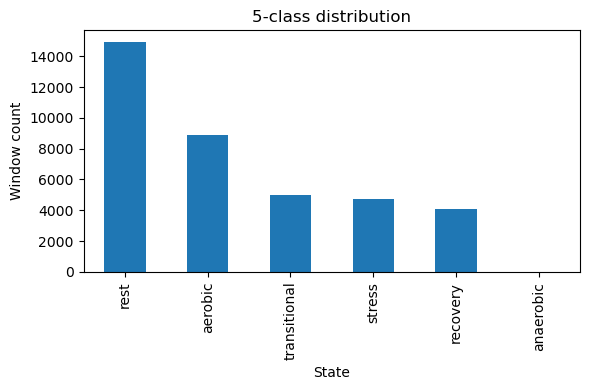

In [153]:
fig, ax = plt.subplots(figsize=(6, 4))

dataset_clean["state_label"].value_counts().plot(kind="bar", ax=ax)

ax.set_title("5-class distribution")
ax.set_xlabel("State")
ax.set_ylabel("Window count")

plt.tight_layout()
plt.show()

Notice, we barely have any anaerobic samples, this is because of the test format itself. The anaerobic spurts are typically less than a minute themselves, and our window size is 60s - so we dont have enough data to work with this class. It will have to be ommited.

### _**Window type distribution, by participant:**_

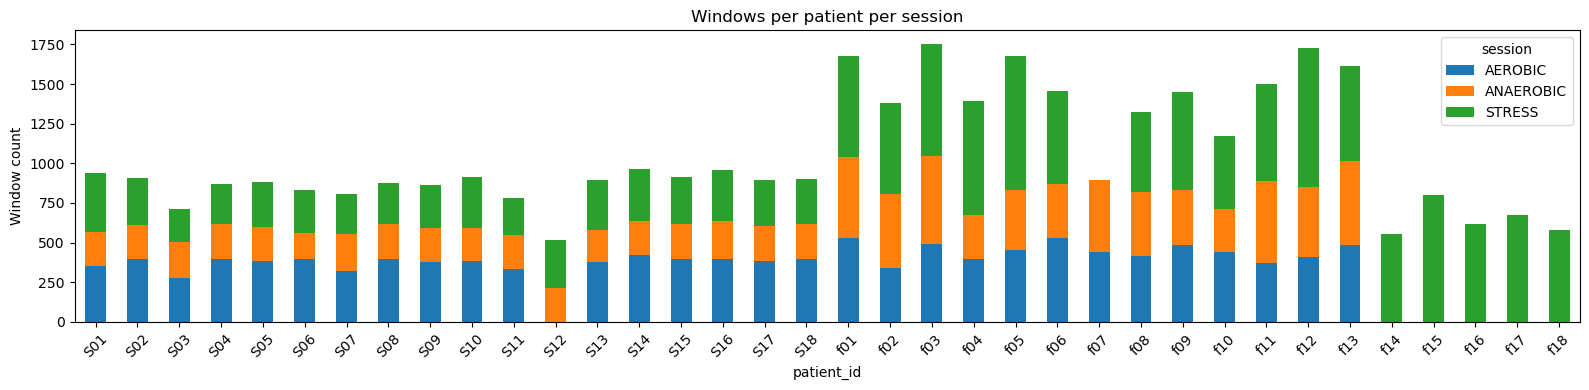

In [157]:
counts = dataset_clean.groupby(["patient_id", "session"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(16, 4))
plt.title("Windows per patient per session")
plt.ylabel("Window count")
plt.xticks(rotation=45)
plt.tight_layout()

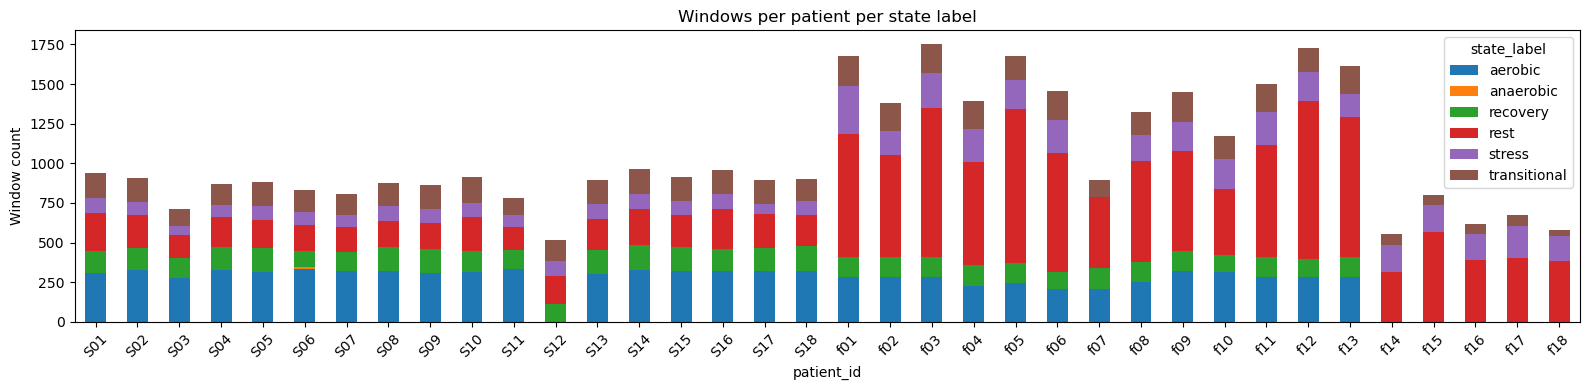

In [158]:
counts = dataset_clean.groupby(["patient_id", "state_label"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(16, 4))
plt.title("Windows per patient per state label")
plt.ylabel("Window count")
plt.xticks(rotation=45)
plt.tight_layout()

### _**Feature distributions by state:**_

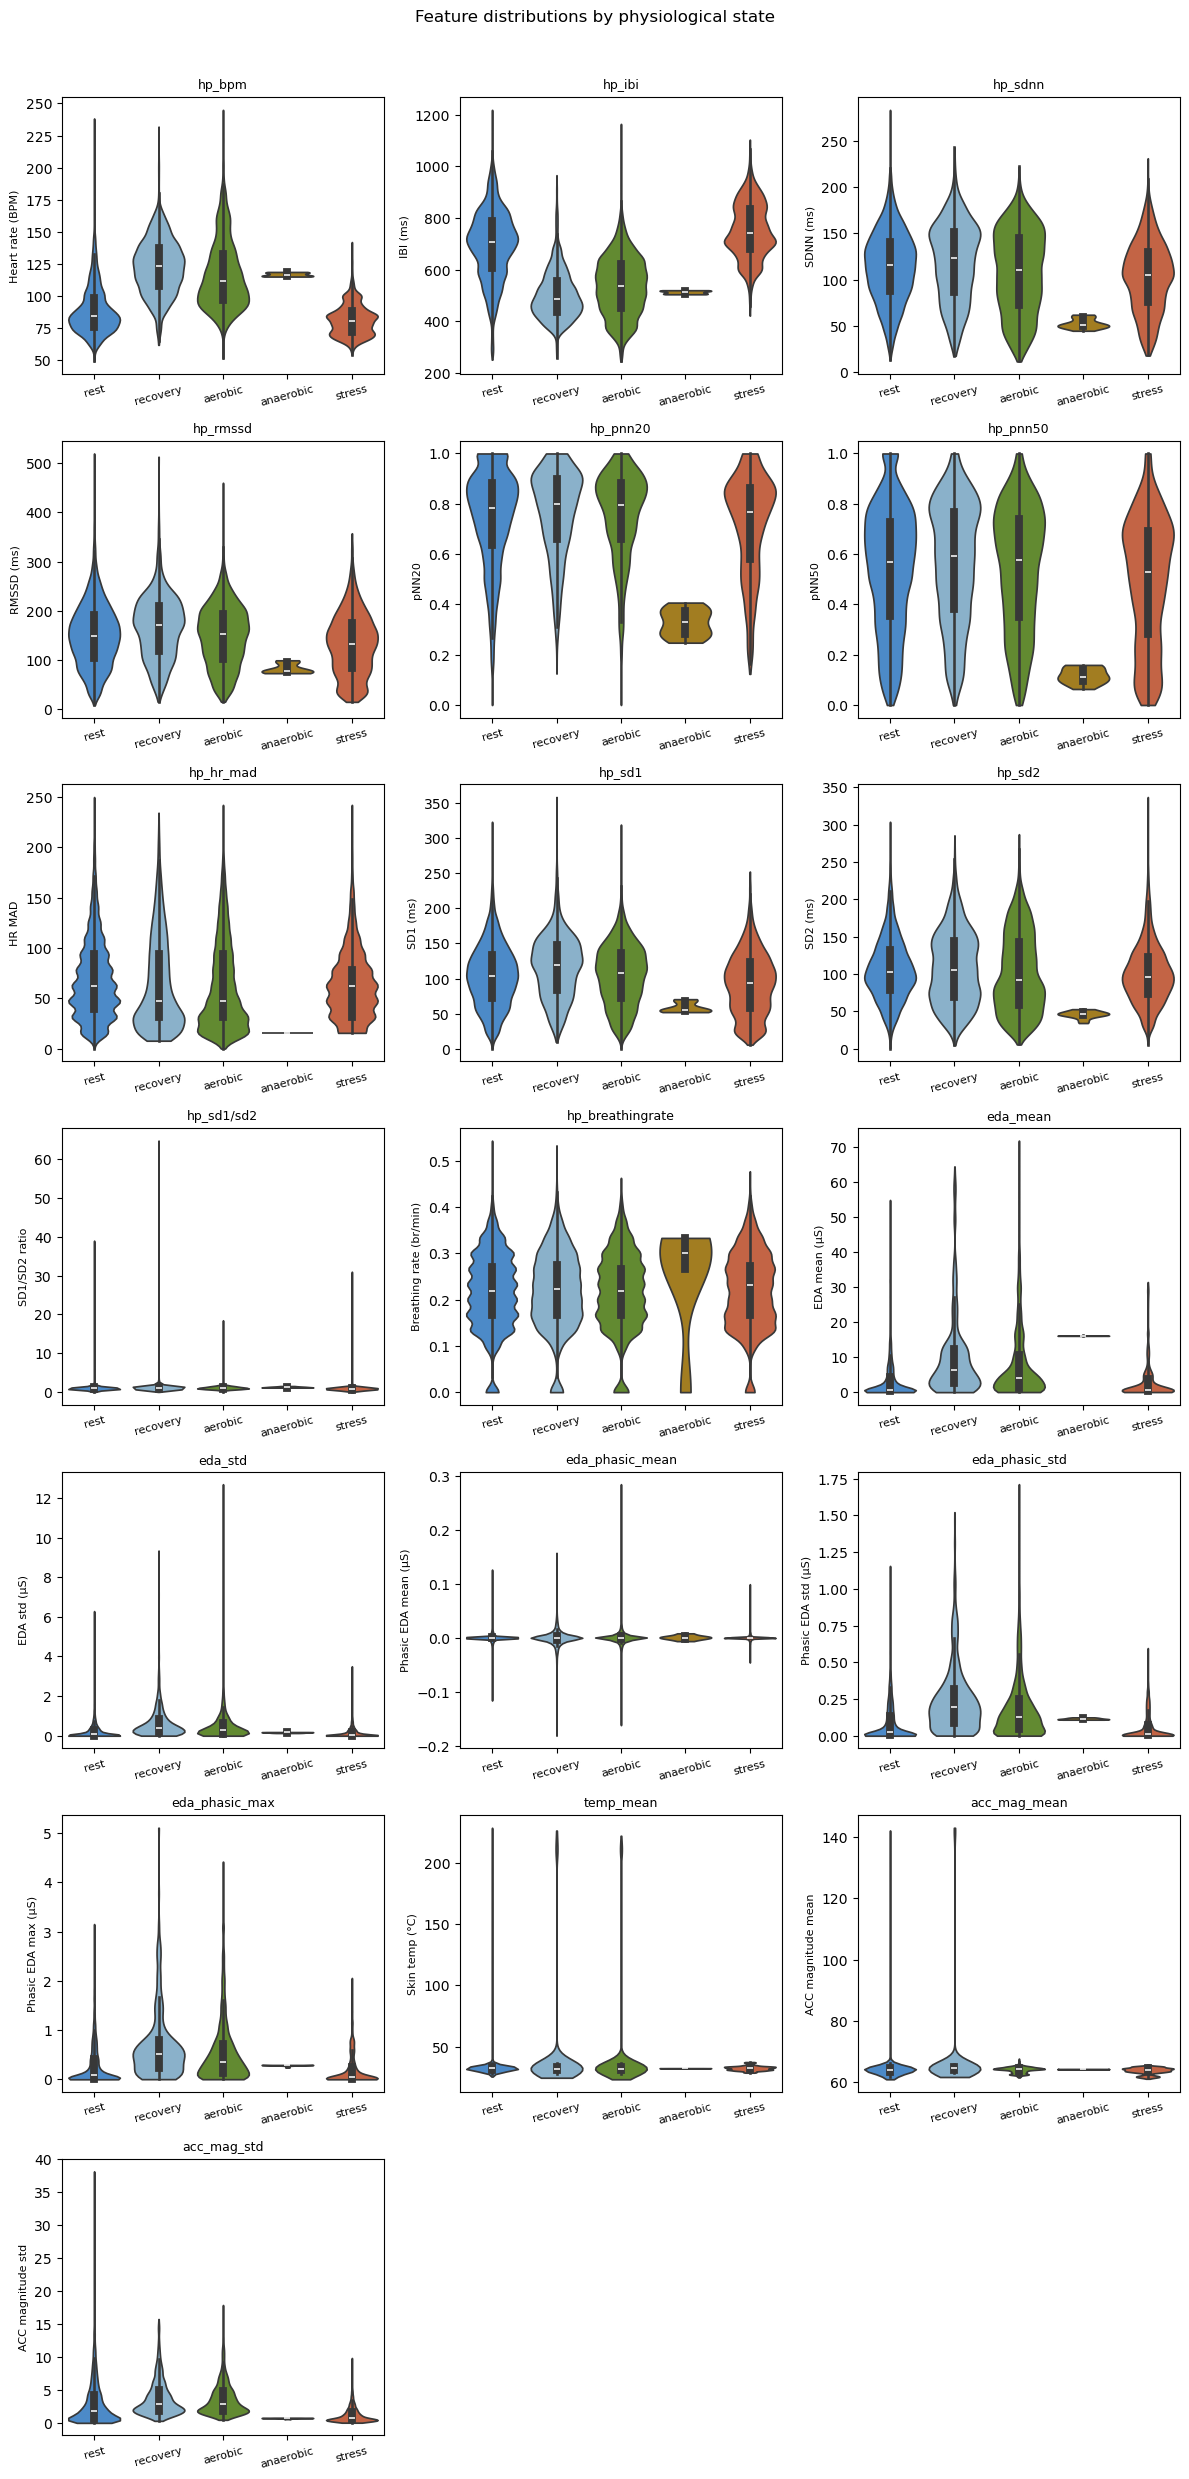

In [161]:
features = [
    # ── HeartPy (full window) ────────────────────────────────
    ("hp_bpm",           "Heart rate (BPM)"),
    ("hp_ibi",           "IBI (ms)"),
    ("hp_sdnn",          "SDNN (ms)"),
    ("hp_rmssd",         "RMSSD (ms)"),
    ("hp_pnn20",         "pNN20"),
    ("hp_pnn50",         "pNN50"),
    ("hp_hr_mad",        "HR MAD"),
    ("hp_sd1",           "SD1 (ms)"),
    ("hp_sd2",           "SD2 (ms)"),
    ("hp_sd1/sd2",       "SD1/SD2 ratio"),
    ("hp_breathingrate", "Breathing rate (br/min)"),
    # ── EDA — full window ────────────────────────────────────
    ("eda_mean",             "EDA mean (µS)"),
    ("eda_std",              "EDA std (µS)"),
    ("eda_phasic_mean",      "Phasic EDA mean (µS)"),
    ("eda_phasic_std",       "Phasic EDA std (µS)"),
    ("eda_phasic_max",       "Phasic EDA max (µS)"),
    # ── TEMP ─────────────────────────────────────────────────
    ("temp_mean",        "Skin temp (°C)"),
    # ── ACC ──────────────────────────────────────────────────
    ("acc_mag_mean",       "ACC magnitude mean"),
    ("acc_mag_std",        "ACC magnitude std"),
]

state_order = ["rest", "recovery", "aerobic", "anaerobic", "stress"]

palette = {
    "rest": "#378ADD",
    "recovery": "#7FB3D5",
    "aerobic": "#639922",
    "anaerobic": "#B8860B",
    "stress": "#D85A30",
}

n_cols = 3
n_rows = -(-len(features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
axes_flat = axes.flatten()

for ax, (col, label) in zip(axes_flat, features):
    sns.violinplot(
        data=dataset_clean,
        x="state_label",
        y=col,
        order=state_order,
        palette=palette,
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelrotation=15, labelsize=8)

for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions by physiological state", y=1.01)
plt.tight_layout()
plt.show()

### _**Feature correlations:**_

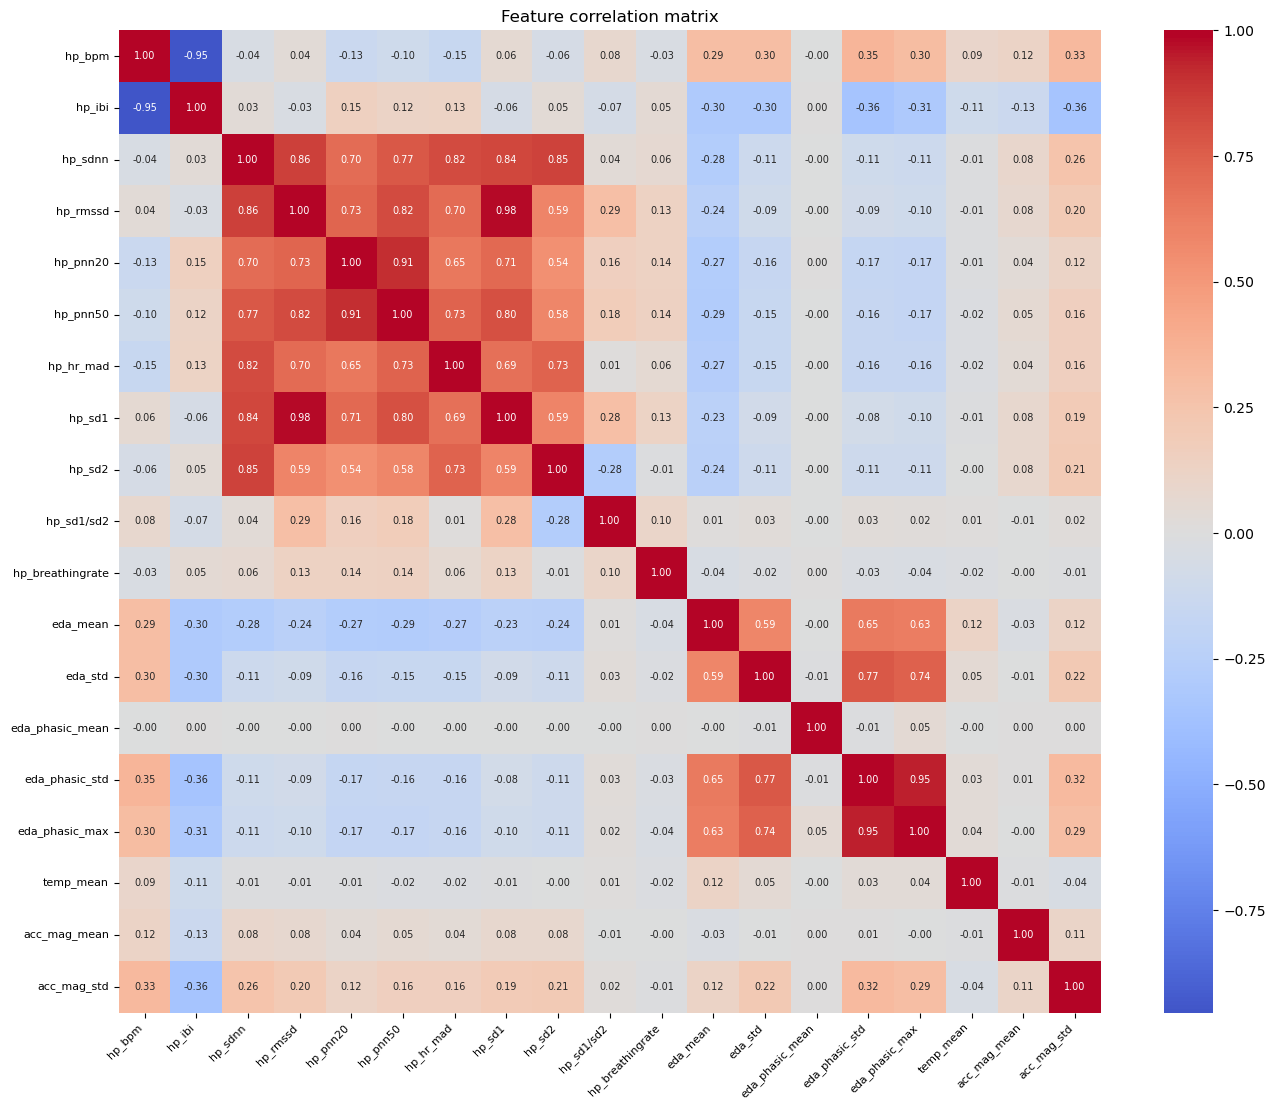

In [163]:
exclude = ["hp_quality_flag", "motion_artifact_flag", "state_label_int"]

numeric_cols = [
    c for c in dataset_clean.columns
    if (
        c.startswith("hp_")
        or c.startswith("eda_")
        or c.startswith("temp_")
        or c.startswith("acc_")
    )
    and c not in exclude
]

corr = dataset_clean[numeric_cols].corr()

n = len(numeric_cols)
fig_size = max(14, n * 0.55)
plt.figure(figsize=(fig_size, fig_size * 0.8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 7},
)
plt.title("Feature correlation matrix")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### _**Seing the transitions for one participant:**_

In [166]:
def view_temporal_reconstruction(pid="f01", sess="STRESS"):
    sub = dataset_clean[
        (dataset_clean["patient_id"] == pid) & (dataset_clean["session"] == sess)
    ].copy().sort_values("t_start_sec").reset_index(drop=True)
    
    state_colors = {
        "rest":       "lightblue",
        "recovery":   "paleturquoise",
        "stress":     "lightsalmon",
        "aerobic":    "lightgreen",
        "anaerobic":  "lightyellow",
    }

    segments = []
    seg_start = sub.loc[0, "t_start_sec"]
    seg_state = sub.loc[0, "state_label"]

    for i in range(1, len(sub)):
        if sub.loc[i, "state_label"] != seg_state:
            segments.append((seg_start, sub.loc[i, "t_start_sec"], seg_state))
            seg_start = sub.loc[i, "t_start_sec"]
            seg_state = sub.loc[i, "state_label"]
    segments.append((seg_start, sub["t_end_sec"].iloc[-1], seg_state))

    phase_changes = sub[sub["phase"] != sub["phase"].shift()]["t_start_sec"].values

    features = ["hp_bpm", "hp_ibi", "eda_phasic_std"]
    colors   = ["coral", "green", "purple"]

    fig, axes = plt.subplots(len(features), 1, figsize=(16, 12), sharex=True)

    for ax, feat, color in zip(axes, features, colors):
        ax.plot(sub["t_start_sec"], sub[feat], color=color, linewidth=0.8)
        ax.set_ylabel(feat)

        for seg_s, seg_e, state in segments:
            ax.axvspan(seg_s, seg_e, alpha=0.25,
                       color=state_colors.get(state, "white"), zorder=0)

        for x in phase_changes:
            ax.axvline(x, color="gray", linestyle="--", linewidth=0.6, alpha=0.7)

    axes[-1].set_xlabel("Time from session start (s)")
    fig.suptitle(f"{pid} — {sess} session: signals over time")
    plt.tight_layout()
    plt.show()

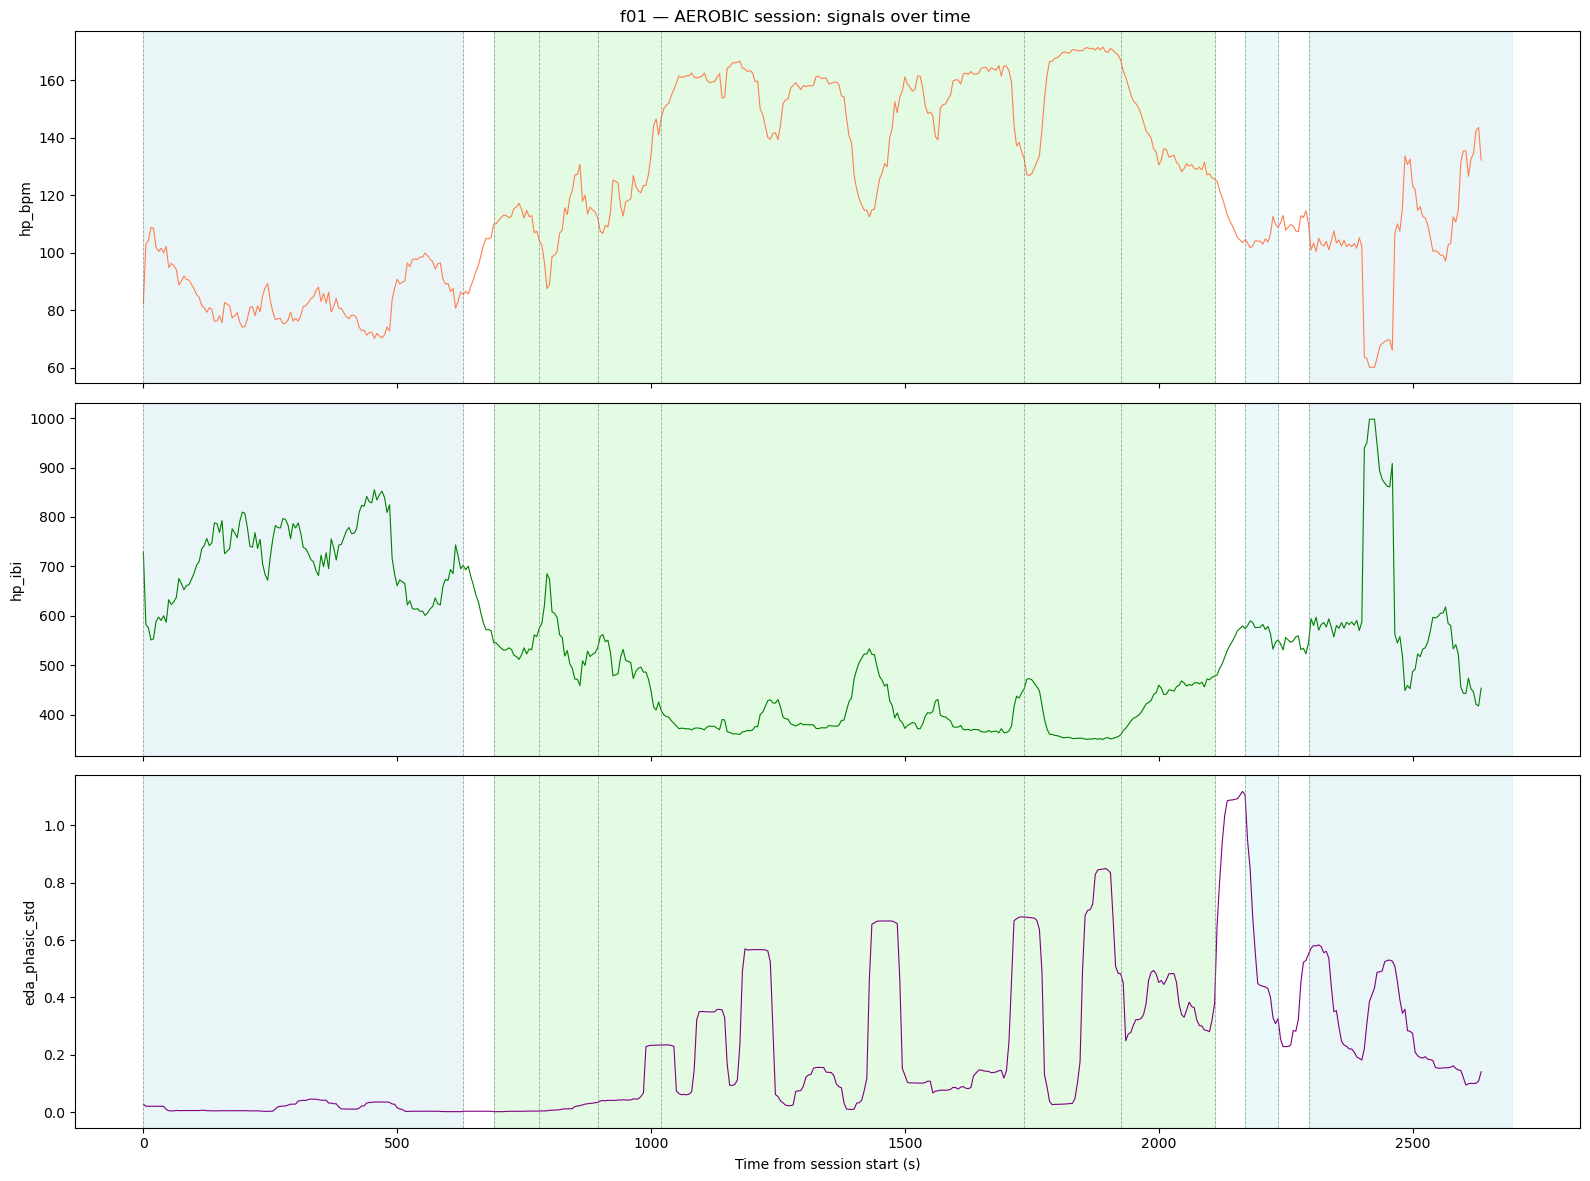

In [167]:
view_temporal_reconstruction(pid="f01", sess="AEROBIC")

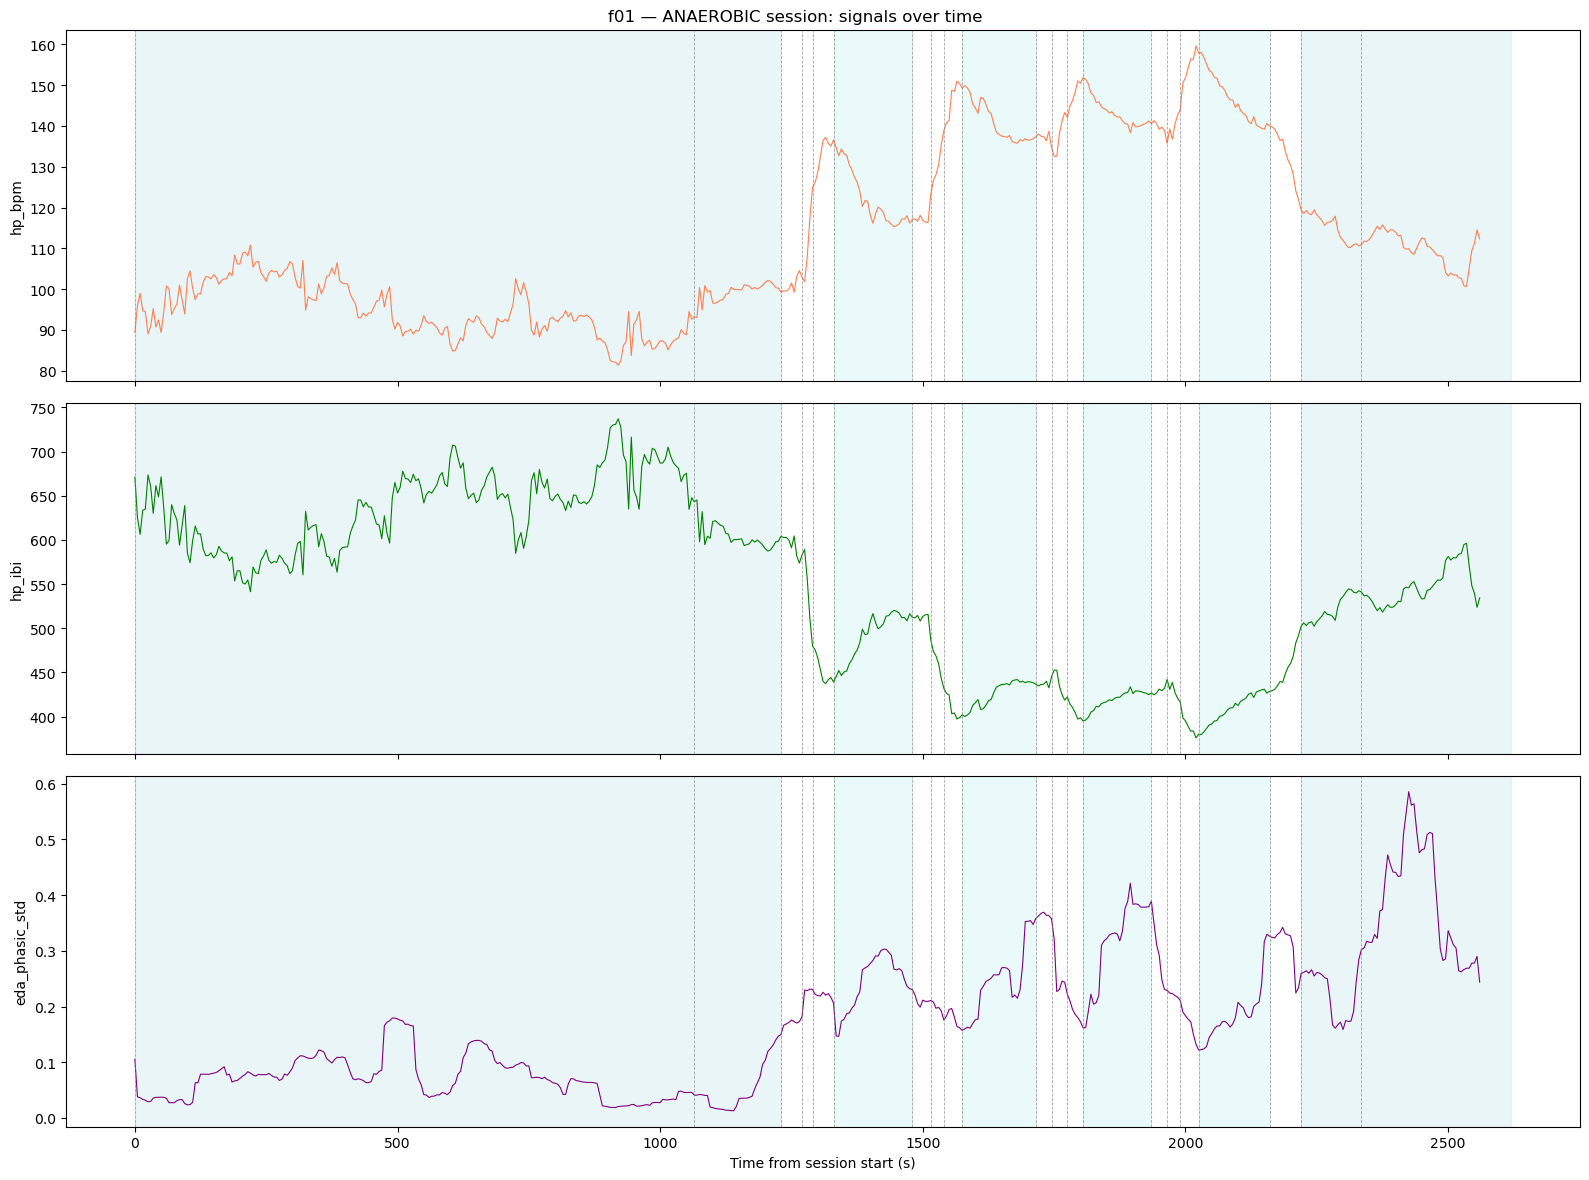

In [168]:
view_temporal_reconstruction(pid="f01", sess="ANAEROBIC")

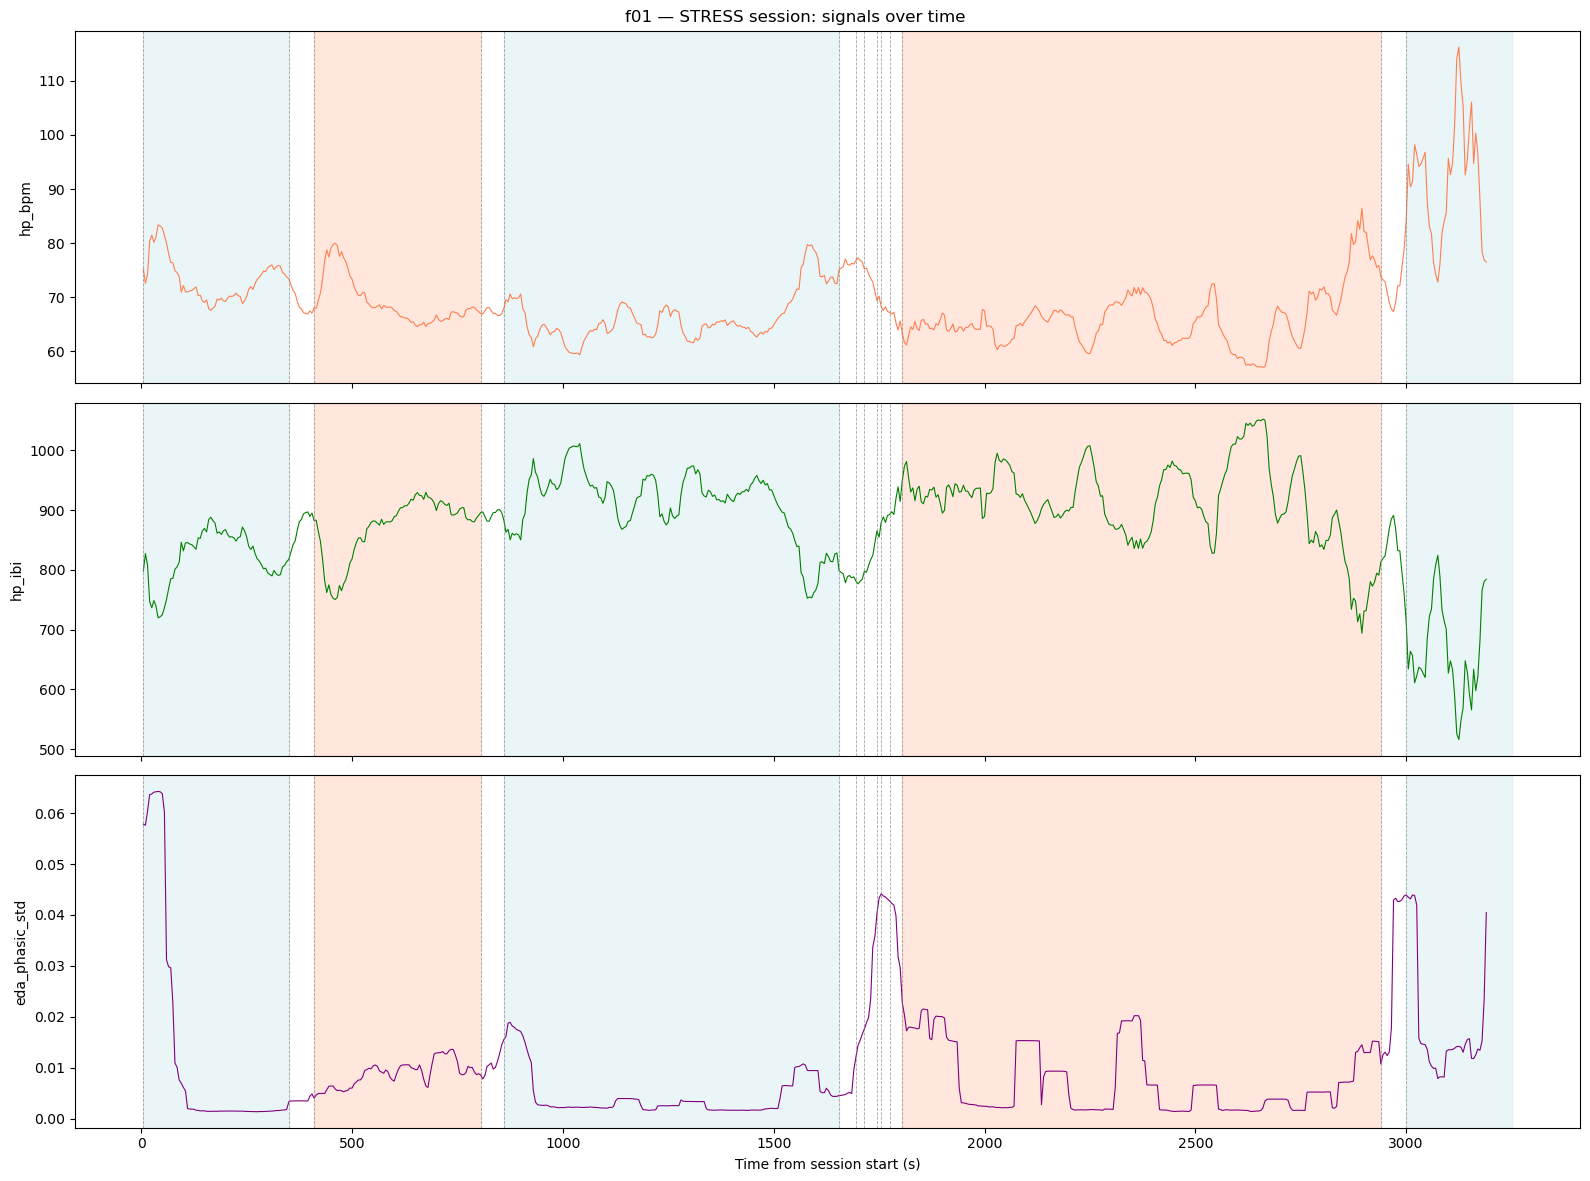

In [169]:
view_temporal_reconstruction(pid="f01", sess="STRESS")

**Note:** The segments in white are transitional.

### _**Inter-subject variability:**_

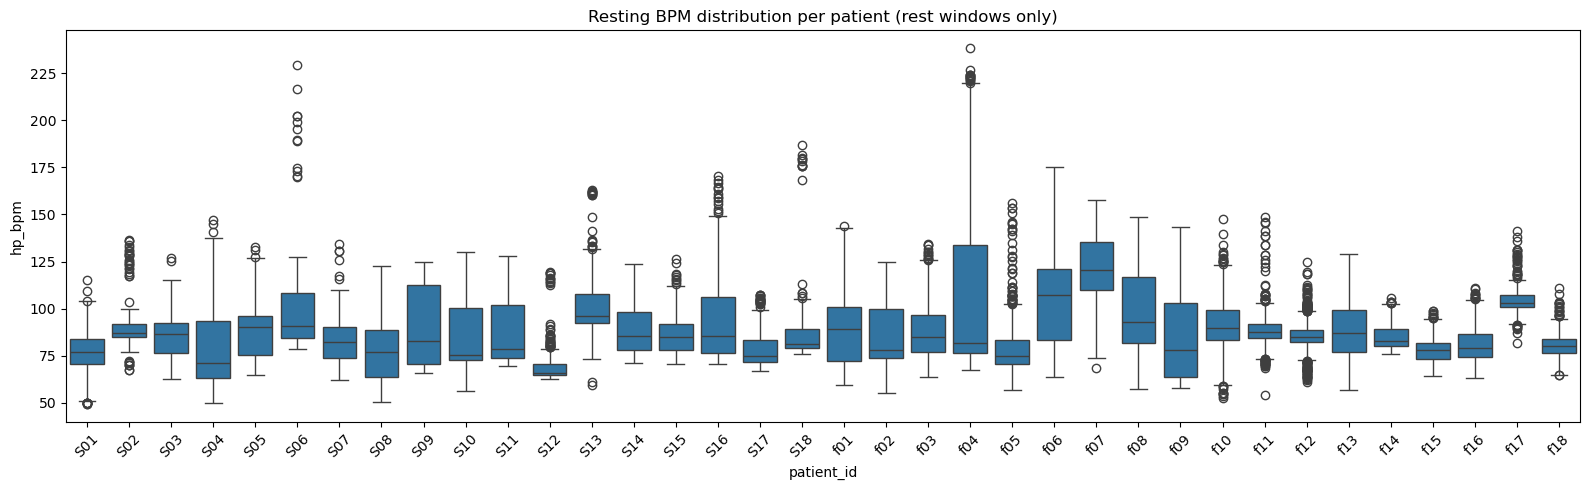

In [172]:
rest_windows = dataset_clean[dataset_clean["state_label"] == "rest"]

plt.figure(figsize=(16, 5))
sns.boxplot(data=rest_windows, x="patient_id", y="hp_bpm", order=sorted(rest_windows["patient_id"].unique()))
plt.xticks(rotation=45)
plt.title("Resting BPM distribution per patient (rest windows only)")
plt.tight_layout()

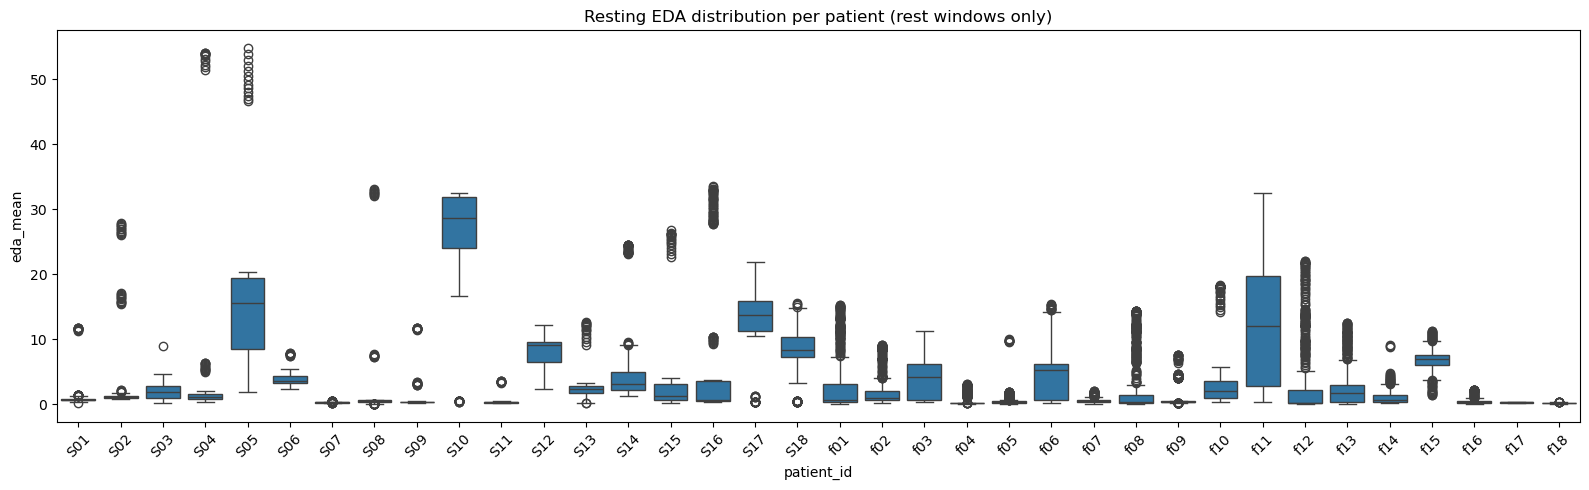

In [173]:
rest_windows = dataset_clean[dataset_clean["state_label"] == "rest"]

plt.figure(figsize=(16, 5))
sns.boxplot(data=rest_windows, x="patient_id", y="eda_mean", order=sorted(rest_windows["patient_id"].unique()))
plt.xticks(rotation=45)
plt.title("Resting EDA distribution per patient (rest windows only)")
plt.tight_layout()